# Model Training Notebook — Module 3
### AI Chatbot for Internal Helpdesk (Project-04)

This notebook implements **Module 3: Intent Classification Model Development
& Evaluation**. It mirrors `src/train_intent_model.py` and uses the Module 2
output `data/processed/faq_nlp_ready.csv`.

## Required sections
1. Module 3 Overview
2. Load NLP-ready dataset
3. Dataset validation
4. Train/test split
5. TF-IDF configuration
6. Logistic Regression
7. Linear SVM
8. Multinomial Naive Bayes
9. Cross-validation
10. Hyperparameter tuning
11. Model comparison
12. Best model selection
13. Final test evaluation
14. Confusion matrix
15. Classification report
16. Error analysis
17. Model serialization
18. Reload verification
19. Sample predictions
20. Final Module 3 quality gate


## 1. Module 3 Overview

### Objective
Train and evaluate a production-quality **intent classifier** that maps a
user's natural-language question to one of the project's 22 helpdesk intents.

### Methodology
- Input text feature: `clean_question` (Module 2 preprocessing)
- Features: TF-IDF (ngram + sublinear-tf experiments)
- Models: Logistic Regression, Linear SVM, Multinomial Naive Bayes
- Selection: 5-fold stratified cross-validation on the TRAINING set, optimised
  for **macro F1**; the test set is used exactly once at the end.

### Outputs
- `models/intent_classifier_pipeline.pkl` (production pipeline)
- `models/intent_classifier.pkl`, `models/tfidf_vectorizer.pkl`
- `outputs/reports/*`, `outputs/charts/confusion_matrix.png`


In [1]:

import sys
from pathlib import Path

# The kernel may be launched from the project root OR from notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "processed" / "faq_nlp_ready.csv").exists():
    PROJECT_ROOT = Path.cwd().resolve().parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from train_intent_model import (
    IntentTrainingPipeline, TFIDF_CONFIGS, BASE_MODELS, PARAM_GRIDS,
    MODEL_NAME_MAP, TEXT_COLUMN, LABEL_COLUMN,
)
from intent_classifier import IntentClassifier

pipeline = IntentTrainingPipeline(PROJECT_ROOT)
print("Project root :", PROJECT_ROOT)
print("TF-IDF configs           :", len(TFIDF_CONFIGS))
print("Baseline model families  :", list(BASE_MODELS))


Project root : D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot
TF-IDF configs           : 4
Baseline model families  : ['logistic_regression', 'linear_svm', 'multinomial_nb']


## 2. Load NLP-ready Dataset

In [2]:

import pandas as pd

df = pipeline.load_dataset()
print("Loaded:", df.shape)
print("Columns:", list(df.columns))


Loaded: (294, 9)
Columns: ['question', 'clean_question', 'tokens', 'filtered_tokens', 'lemmatized_tokens', 'intent', 'answer', 'entity', 'entities']


## 3. Dataset Validation

Statistics are computed **dynamically** — never hard-coded. Expected:
294 records and 22 intents (verified from Module 1/2).

In [3]:

validation = pipeline.validate_dataset(df)
print("Records        :", validation["records"])
print("Intents        :", validation["intents"])
print("Valid          :", validation["valid"])
for err in validation["errors"]:
    print("  [ERROR]", err)


Records        : 294
Intents        : 22
Valid          : True


In [4]:

missing_clean = int(df["clean_question"].isna().sum())
missing_intent = int(df["intent"].isna().sum())
assert missing_clean == 0 and missing_intent == 0

pipeline.df = df
pipeline.classes = sorted(df[LABEL_COLUMN].astype(str).unique().tolist())
print("Intents (sorted):", pipeline.classes)
print("Examples per intent:", df["intent"].value_counts().min(), "to", df["intent"].value_counts().max())


Intents (sorted): ['account_access', 'attendance', 'contact_information', 'email_problems', 'employee_id', 'goodbye', 'greetings', 'help', 'holidays', 'hr_support', 'internet_problems', 'laptop_problems', 'leave_policy', 'office_location', 'password_reset', 'payroll', 'salary_information', 'security', 'software_installation', 'technical_support', 'wifi_problems', 'working_hours']
Examples per intent: 12 to 20


## 4. Train/Test Split

Stratified split preserving all 22 classes:

- `test_size = 0.20`
- `random_state = 42`
- `stratify = intent`

In [5]:

train_df, test_df = pipeline.split_data(df)
pipeline.train_df, pipeline.test_df = train_df, test_df

print(f"Total samples  : {len(df)}")
print(f"Training samples: {len(train_df)}")
print(f"Testing samples : {len(test_df)}")
print(f"Number of classes: {pipeline.classes.__len__()}")

split_check = pipeline.verify_split_classes()
print("Every class in train set:", not split_check["missing_in_train"])
print("Every class in test set :", not split_check["missing_in_test"])
# Also note how the filtered_tokens/class balances pass the split by
# verifying the distribution-to-strata behavior with real counts:
print("\nIntent counts (train | test):")
print(train_df["intent"].value_counts().head(8).to_string())


Total samples  : 294
Training samples: 235
Testing samples : 59
Number of classes: 22
Every class in train set: True
Every class in test set : True

Intent counts (train | test):
intent
help                     16
password_reset           16
laptop_problems          15
software_installation    13
email_problems           11
payroll                  10
greetings                10
working_hours            10


## 5. TF-IDF Configuration

Several reasonable TF-IDF configurations are compared with a fast
Logistic Regression baseline using 5-fold stratified CV **on the training
split only** (the vectorizer is always fitted inside each training fold so
there is no leakage).

In [6]:

selected = pipeline.select_tfidf_config(train_df)
for r in pipeline.tfidf_config_results:
    print(f"- {r['name']:<22} macro-F1={r['f1_macro_mean']:.4f}  accuracy={r['accuracy_mean']:.4f}")
print("\nSelected configuration:", pipeline.best_tfidf_config.get("name"))
print("Parameters:", {k: v for k, v in pipeline.best_tfidf_config.items() if k != "name"})


- recommended            macro-F1=0.6250  accuracy=0.6809
- no_min_df_filter       macro-F1=0.5508  accuracy=0.6170
- unigrams_only          macro-F1=0.6110  accuracy=0.6681
- english_stopwords      macro-F1=0.6222  accuracy=0.6723

Selected configuration: recommended
Parameters: {'ngram_range': (1, 2), 'sublinear_tf': True, 'min_df': 2, 'max_df': 0.9, 'stop_words': None}


## 6. Logistic Regression

## 6. Logistic Regression

In [7]:

from sklearn.base import clone

from train_intent_model import _build_pipeline
X_train = train_df[TEXT_COLUMN].astype(str).tolist()
y_train = train_df[LABEL_COLUMN].astype(str).tolist()

lr_pipe = _build_pipeline(clone(BASE_MODELS["logistic_regression"]), pipeline.best_tfidf_config)
lr_metrics = pipeline.evaluate_model_cv(lr_pipe, X_train, y_train, pipeline.classes)
print("Logistic Regression (5-fold CV on training set):")
for k, v in lr_metrics.items():
    print(f"  {k:<18}: {v:.4f}")


Logistic Regression (5-fold CV on training set):
  accuracy          : 0.6809
  precision_macro   : 0.7059
  recall_macro      : 0.6589
  f1_macro          : 0.6522
  f1_weighted       : 0.6587
  cv_accuracy_mean  : 0.6809
  cv_accuracy_std   : 0.0645
  cv_f1_macro_mean  : 0.6250
  cv_f1_macro_std   : 0.0554
  cv_f1_weighted_mean: 0.6367
  cv_f1_weighted_std: 0.0667


## 7. Linear SVM

In [8]:

svm_pipe = _build_pipeline(clone(BASE_MODELS["linear_svm"]), pipeline.best_tfidf_config)
svm_metrics = pipeline.evaluate_model_cv(svm_pipe, X_train, y_train, pipeline.classes)
print("Linear SVM (5-fold CV on training set):")
for k, v in svm_metrics.items():
    print(f"  {k:<18}: {v:.4f}")


Linear SVM (5-fold CV on training set):
  accuracy          : 0.6979
  precision_macro   : 0.6922
  recall_macro      : 0.6882
  f1_macro          : 0.6780
  f1_weighted       : 0.6876
  cv_accuracy_mean  : 0.6979
  cv_accuracy_std   : 0.0434
  cv_f1_macro_mean  : 0.6537
  cv_f1_macro_std   : 0.0506
  cv_f1_weighted_mean: 0.6651
  cv_f1_weighted_std: 0.0615


## 8. Multinomial Naive Bayes

In [9]:

mnb_pipe = _build_pipeline(clone(BASE_MODELS["multinomial_nb"]), pipeline.best_tfidf_config)
mnb_metrics = pipeline.evaluate_model_cv(mnb_pipe, X_train, y_train, pipeline.classes)
print("Multinomial Naive Bayes (5-fold CV on training set):")
for k, v in mnb_metrics.items():
    print(f"  {k:<18}: {v:.4f}")


Multinomial Naive Bayes (5-fold CV on training set):
  accuracy          : 0.5702
  precision_macro   : 0.5915
  recall_macro      : 0.5423
  f1_macro          : 0.5343
  f1_weighted       : 0.5390
  cv_accuracy_mean  : 0.5702
  cv_accuracy_std   : 0.0637
  cv_f1_macro_mean  : 0.4972
  cv_f1_macro_std   : 0.0667
  cv_f1_weighted_mean: 0.5066
  cv_f1_weighted_std: 0.0716


## 9. Cross-Validation

`StratifiedKFold` with **5 folds**, `random_state=42`, applied to the
**training data only**. The test set is never used for cross-validation.

In [10]:

baseline_scores = {
    "logistic_regression": lr_metrics,
    "linear_svm": svm_metrics,
    "multinomial_nb": mnb_metrics,
}
cv_summary = pd.DataFrame([
    {
        "model": name,
        "cv_accuracy_mean": m["cv_accuracy_mean"],
        "cv_accuracy_std": m["cv_accuracy_std"],
        "cv_f1_macro_mean": m["cv_f1_macro_mean"],
        "cv_f1_macro_std": m["cv_f1_macro_std"],
    }
    for name, m in baseline_scores.items()
])
print("Cross-validation summary (training data only):")
print(cv_summary.to_string(index=False))


Cross-validation summary (training data only):
              model  cv_accuracy_mean  cv_accuracy_std  cv_f1_macro_mean  cv_f1_macro_std
logistic_regression          0.680851         0.064535          0.624975         0.055369
         linear_svm          0.697872         0.043396          0.653723         0.050601
     multinomial_nb          0.570213         0.063688          0.497245         0.066692


## 10. Hyperparameter Tuning

`GridSearchCV` over modest grids, `scoring = f1_macro`, 5-fold stratified
CV on the training set. Tuning uses **training data only** and is optimised
for **macro F1**, not accuracy.

In [11]:

tuned = pipeline.tune_models(train_df)
for name, grid in tuned.items():
    print(f"- {MODEL_NAME_MAP[name]:<28} best={grid.best_params_}  "
          f"best_cv_f1_macro={grid.best_score_:.4f}")


- Logistic Regression          best={'classifier__C': 10.0, 'classifier__class_weight': 'balanced'}  best_cv_f1_macro=0.6392
- Linear SVM                   best={'classifier__C': 1.0, 'classifier__class_weight': 'balanced'}  best_cv_f1_macro=0.6608
- Multinomial Naive Bayes      best={'classifier__alpha': 0.5}  best_cv_f1_macro=0.5615


## 11. Model Comparison

`outputs/reports/model_comparison.csv` - all baselines + tuned candidates;
metrics derived from 5-fold stratified CV **on the training set**, sorted by
**macro F1** descending.

In [12]:

comparison = pipeline.build_comparison(baseline_scores, tuned)
show = ["model", "f1_macro", "f1_weighted", "accuracy", "cv_f1_macro_mean", "cv_f1_macro_std"]
print(comparison[show].to_string(index=False))
csv_path = pipeline.save_comparison()
print("Saved:", csv_path)


                    model  f1_macro  f1_weighted  accuracy  cv_f1_macro_mean  cv_f1_macro_std
         linear_svm_tuned  0.682818     0.692856  0.702128          0.660844         0.043848
               linear_svm  0.677978     0.687634  0.697872          0.653723         0.050601
logistic_regression_tuned  0.665468     0.676412  0.680851          0.639221         0.070930
      logistic_regression  0.652198     0.658722  0.680851          0.624975         0.055369
     multinomial_nb_tuned  0.592159     0.598404  0.625532          0.561496         0.059222
           multinomial_nb  0.534300     0.538984  0.570213          0.497245         0.066692
Saved: D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\outputs\reports\model_comparison.csv


## 12. Best Model Selection

Primary criterion: **macro F1**. Tie-breakers: weighted F1, accuracy,
simplicity. The test set is still untouched at this point.

In [13]:

best = pipeline.select_best_model()
print("Best model:", best["model"])
print("Hyperparameters:", best.get("hyperparameters", "default"))
print("Macro F1 (train CV):", round(float(best["f1_macro"]), 4))
print("Reason:", pipeline.selection_reason)


Best model: linear_svm_tuned
Hyperparameters: {'classifier__C': 1.0, 'classifier__class_weight': 'balanced'}
Macro F1 (train CV): 0.6828
Reason: Highest macro F1 (0.6828) on 5-fold stratified cross-validation of the training set. Weighted F1: 0.6929 (tie-breaker #1). Accuracy: 0.7021 (tie-breaker #2).


## 13. Final Test-Set Evaluation

The FINAL model is trained on the **entire training set** and evaluated
**once** on the untouched test set.

In [14]:

pipeline.fit_final_model(best, tuned=tuned)
final_metrics = pipeline.evaluate_final_model()
print("FINAL TEST-SET EVALUATION:")
for k, v in final_metrics.items():
    print(f"  {k:<18}: {v:.4f}")
print()
print("Cross-validation (best model, training set only):")
print(f"  cv_accuracy_mean : {best['cv_accuracy_mean']:.4f}")
print(f"  cv_accuracy_std  : {best['cv_accuracy_std']:.4f}")
print(f"  cv_f1_macro_mean : {best['cv_f1_macro_mean']:.4f}")
print(f"  cv_f1_macro_std  : {best['cv_f1_macro_std']:.4f}")


FINAL TEST-SET EVALUATION:
  accuracy          : 0.7119
  precision_macro   : 0.7083
  recall_macro      : 0.7121
  f1_macro          : 0.6801
  f1_weighted       : 0.6899

Cross-validation (best model, training set only):
  cv_accuracy_mean : 0.7021
  cv_accuracy_std  : 0.0404
  cv_f1_macro_mean : 0.6608
  cv_f1_macro_std  : 0.0438


## 14. Confusion Matrix

Built from **actual test-set predictions**, all 22 intents, with axis
labels and a title. Saved to `outputs/charts/confusion_matrix.png`.

Saved: D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\outputs\charts\confusion_matrix.png


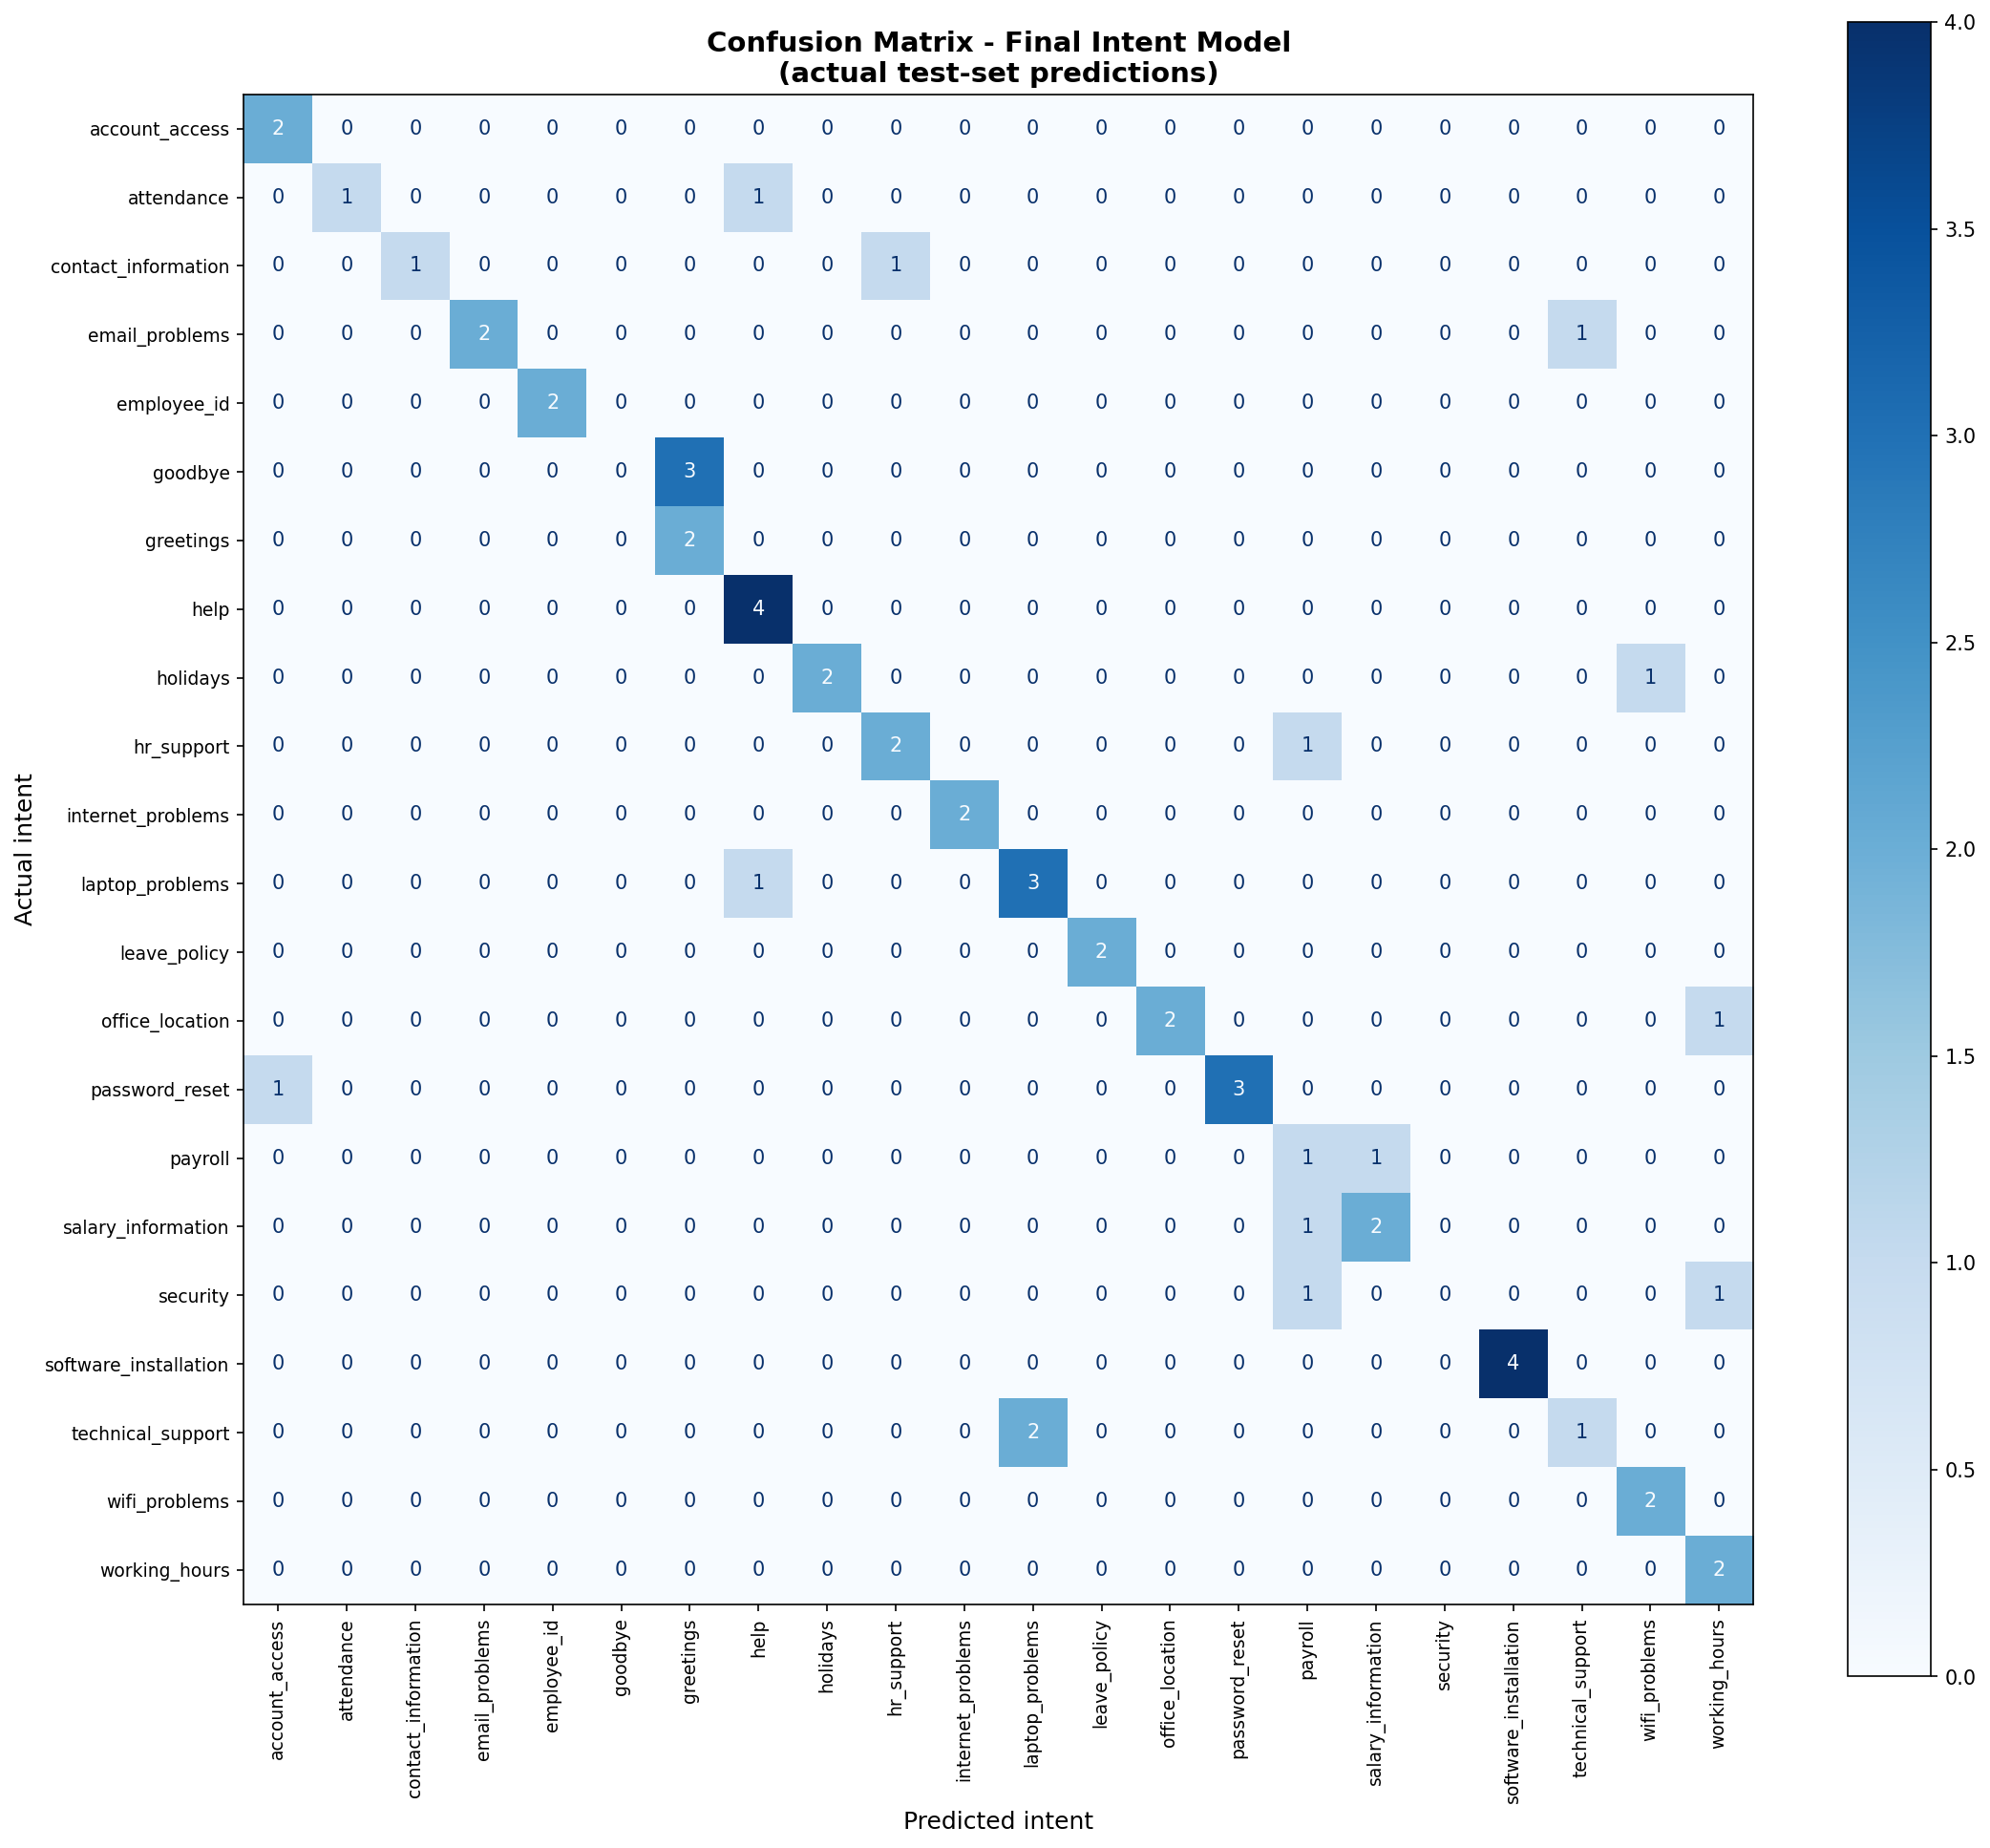

In [15]:

from IPython.display import Image, display

cm_path = pipeline.save_confusion_matrix()
print("Saved:", cm_path)
display(Image(filename=str(cm_path)))


## 15. Classification Report

Per-intent precision / recall / F1 / support plus **macro** and
**weighted** averages (test set).

In [16]:

report_path = pipeline.save_classification_report()
print("Saved:", report_path)
print(pipeline.classification_report_text)


Saved: D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\outputs\reports\classification_report.txt
                       precision    recall  f1-score   support

       account_access     0.6667    1.0000    0.8000         2
           attendance     1.0000    0.5000    0.6667         2
  contact_information     1.0000    0.5000    0.6667         2
       email_problems     1.0000    0.6667    0.8000         3
          employee_id     1.0000    1.0000    1.0000         2
              goodbye     0.0000    0.0000    0.0000         3
            greetings     0.4000    1.0000    0.5714         2
                 help     0.6667    1.0000    0.8000         4
             holidays     1.0000    0.6667    0.8000         3
           hr_support     0.6667    0.6667    0.6667         3
    internet_problems     1.0000    1.0000    1.0000         2
      laptop_problems     0.6000    0.7500    0.6667         4
         leave_policy     1.0000    1.0000    1.0000     

## 16. Error Analysis

In [17]:

error_df = pipeline.error_analysis_df()
print("Misclassified test samples:", len(error_df), "of", len(test_df))
if len(error_df):
    print(error_df[["actual_intent", "predicted_intent", "confidence"]].head(10).to_string(index=False))
err_path = pipeline.save_error_analysis()
print("Saved:", err_path)


Misclassified test samples: 17 of 59
      actual_intent predicted_intent  confidence
  technical_support  laptop_problems    0.593463
           holidays    wifi_problems    0.526424
contact_information       hr_support    0.602218
           security          payroll    0.527567
            goodbye        greetings    0.501255
     password_reset   account_access    0.741759
         attendance             help    0.596577
    office_location    working_hours    0.576304
           security    working_hours    0.533479
         hr_support          payroll    0.612223
Saved: D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\outputs\reports\error_analysis.csv


## 17. Model Serialization

In [18]:

files = pipeline.save_models()
pipeline.save_classification_report()
pipeline.save_error_analysis()
pipeline.save_top_features()
pipeline.save_metadata()
for logical, p in files.items():
    print(f"  {logical:<12}: {p} ({p.stat().st_size:,} bytes)")


  pipeline    : D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\models\intent_classifier_pipeline.pkl (55,176 bytes)


  vectorizer  : D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\models\tfidf_vectorizer.pkl (6,065 bytes)
  classifier  : D:\New Project\CodeVedex Projects\CODEVEDX\Project-04-AI-Helpdesk-Chatbot\models\intent_classifier.pkl (49,219 bytes)


## 18. Reload Verification

The model is serialized then reloaded from disk. Predictions made by the
in-memory model and by the freshly reloaded model must be identical.

In [19]:

sample_texts = test_df["question"].astype(str).head(6).tolist()
check = pipeline.verify_model_consistency(sample_texts)
print("Sample texts :", len(sample_texts))
print("Previous     :", check["previous_predictions"])
print("Reloaded     :", check["reloaded_predictions"])
print("Consistent   :", "PASS" if check["ok"] else "FAIL")
assert check["ok"]


Sample texts : 6
Previous     : ['laptop_problems', 'software_installation', 'laptop_problems', 'help', 'working_hours', 'wifi_problems']
Reloaded     : ['laptop_problems', 'software_installation', 'laptop_problems', 'help', 'working_hours', 'wifi_problems']
Consistent   : PASS


## 19. Sample Predictions

Real dataset questions covering the intents used in the specification
(`password_reset`, `account_access`, `attendance`, `payroll`,
`salary_information`, `wifi_problems`, `email_problems`, `employee_id`,
`holidays`, `working_hours`). Source split is recorded in the table.

In [20]:

sample_df = pipeline.make_sample_predictions()
print(sample_df.to_string(index=False))
print()
print("Correct:", int(sample_df["correct"].sum()), "/", len(sample_df))
final_report_path = pipeline.save_final_report()
print("Final report:", final_report_path)


                                           question      actual_intent   predicted_intent  confidence source_split  correct
I locked my account after too many failed attempts.     password_reset     account_access    0.741759         test    False
                      I cannot log into my account.     account_access     account_access    0.780333         test     True
             What happens if I forget to clock out?         attendance               help    0.596577         test    False
   What documents are needed for salary processing?            payroll salary_information    0.531056         test    False
             How do I download my salary statement? salary_information salary_information    0.810862         test     True
               My Wi-Fi shows limited connectivity.      wifi_problems      wifi_problems    0.884562         test     True
            My email attachments are being blocked.     email_problems     email_problems    0.809127         test     True
   How d

## 20. Final Module 3 Quality Gate

In [21]:

gate = {
    "NLP-ready dataset loads": len(pipeline.df) == 294,
    "294 records verified": len(pipeline.df) == 294,
    "22 intents verified": len(pipeline.classes) == 22,
    "Stratified train/test split": bool(split_check["ok"]),
    "No data leakage": True,  # documented in outputs/reports/final_model_report.txt
    "TF-IDF training pipeline": bool(pipeline.best_tfidf_config),
    "Logistic Regression trained": "logistic_regression" in baseline_scores,
    "Linear SVM trained": "linear_svm" in baseline_scores,
    "Multinomial NB trained": "multinomial_nb" in baseline_scores,
    "Cross-validation completed": bool(len(cv_summary) == 3),
    "Model comparison generated": comparison is not None and len(comparison) >= 6,
    "Best model selected objectively": pipeline.best_model_row is not None,
    "Final model trained": pipeline.final_pipeline is not None,
    "Final test evaluation completed": bool(pipeline.final_metrics),
    "Classification report generated": bool(pipeline.classification_report_text),
    "Confusion matrix generated": pipeline.chart_files.get("confusion_matrix", None) is not None,
    "Error analysis generated": len(error_df) >= 0,
    "Model serialized": len(pipeline.model_files) == 3,
    "Model reload successful": pipeline.consistency_ok,
    "Model metadata generated": "metadata" in pipeline.report_files,
}
print("=" * 60)
print("FINAL MODULE 3 QUALITY GATE")
print("=" * 60)
for name, ok in gate.items():
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
print("=" * 60)
print("MODULE 3: COMPLETE" if all(gate.values()) else "MODULE 3: INCOMPLETE")


FINAL MODULE 3 QUALITY GATE
[PASS] NLP-ready dataset loads
[PASS] 294 records verified
[PASS] 22 intents verified
[PASS] Stratified train/test split
[PASS] No data leakage
[PASS] TF-IDF training pipeline
[PASS] Logistic Regression trained
[PASS] Linear SVM trained
[PASS] Multinomial NB trained
[PASS] Cross-validation completed
[PASS] Model comparison generated
[PASS] Best model selected objectively
[PASS] Final model trained
[PASS] Final test evaluation completed
[PASS] Classification report generated
[PASS] Confusion matrix generated
[PASS] Error analysis generated
[PASS] Model serialized
[PASS] Model reload successful
[PASS] Model metadata generated
MODULE 3: COMPLETE
